# Jaguar Re-Identification - Transformers Baseline

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [13]:
train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test pairs: {len(test_pairs_df)}")

Train: 1516 images
Val:   379 images
Test pairs: 137270


In [14]:
def load_images_from_df(df, img_dir):
    images, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading images...")
X_train, y_train = load_images_from_df(train_df, TRAIN_IMG_DIR)
X_val, y_val = load_images_from_df(val_df, TRAIN_IMG_DIR)
test_images = load_test_images(TEST_IMG_DIR)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, test: {len(test_images)}")

Loading images...
X_train: (1516, 224, 224, 3), X_val: (379, 224, 224, 3), test: 371


## 2. Vision Transformer architecture

Naive Vision Transformer (ViT) baseline.  
- Patch embedding: Conv2D(16x16, stride 16) splits 224x224 image into 14x14 = 196 patches  
- Positional embedding: one-hot position concatenated to each patch embedding  
- L transformer blocks with self-attention (Q, K, V) + feed-forward + residual connections  
- Flatten + Dense for classification

In [15]:
def positional_embedding(embedded_patches):
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def create_naive_too_simple_vision_transformer(input_shape, num_classes, embedding_dim=8, transformer_blocks_count=3):
    input_tensor = keras.Input(input_shape)

    x = input_tensor

    x = keras.layers.Conv2D(embedding_dim, (16, 16), strides=(16, 16), activation=keras.activations.linear, use_bias=False, padding='valid')(x)
    # 14, 14, embedding_dim
    sequence_length = x.shape[1] * x.shape[2]
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = keras.layers.Reshape((sequence_length, embedding_dim))(x)
    # 196, embedding_dim

    x = keras.layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + embedding_dim

    for _ in range(transformer_blocks_count): # L
        old_x = x
        x = keras.layers.LayerNormalization()(x)

        Q = keras.layers.Dense(real_embedding_dim, activation=keras.activations.tanh)(x)
        K = keras.layers.Dense(real_embedding_dim, activation=keras.activations.tanh)(x)
        V = keras.layers.Dense(real_embedding_dim, activation=keras.activations.tanh)(x)

        Kt = keras.layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = keras.layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = keras.layers.Softmax()(QKt)
        x = keras.layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = keras.layers.Add()([x, old_x])
        old_x = x
        x = keras.layers.LayerNormalization()(x)
        x = keras.layers.Dense(real_embedding_dim, activation=keras.activations.tanh)(x)
        x = keras.layers.Dense(real_embedding_dim, activation=keras.activations.tanh)(x)
        x = keras.layers.Add()([x, old_x])

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(real_embedding_dim, activation=keras.activations.tanh)(x)
    output_tensor = keras.layers.Dense(num_classes, activation=keras.activations.softmax)(x)

    model = keras.Model(input_tensor, output_tensor)
    return model

vit = create_naive_too_simple_vision_transformer((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
vit.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14, 8) │      6,144 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 196, 8)    │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 196, 204)  │          0 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 204)  │        408 │ lambda_10[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 196, 204)  │     41,820 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 196, 204)  │     41,820 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 204, 196)  │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 196, 196)  │          0 │ dense_17[0][0],   │
│                     │                   │            │ lambda_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_3 (Softmax) │ (None, 196, 196)  │          0 │ lambda_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 196, 204)  │     41,820 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 196, 204)  │          0 │ softmax_3[0][0],  │
│                     │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 196, 204)  │          0 │ lambda_13[0][0],  │
│                     │                   │            │ lambda_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 204)  │        408 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 196, 204)  │     41,820 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 196, 204)  │     41,820 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 196, 204)  │          0 │ dense_21[0][0],   │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 204)  │        408 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 196, 204)  │     41,820 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 196, 204)  │     41,820 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_14 (Lambda)  │ (None, 204, 196)  │          0 │ dense_23[0][0]  

 Total params: 8,799,187 (33.57 MB)

 Trainable params: 8,799,187 (33.57 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [16]:
vit.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vit_log_dir = os.path.join(LOG_DIR, 'transformers_baseline', datetime.now().strftime('%Y%m%d-%H%M%S'))

vit_history = vit.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.TensorBoard(log_dir=vit_log_dir, histogram_freq=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50


I0000 00:00:1773414172.598908   25032 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19473__.100


43/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0471 - loss: 5.1973

I0000 00:00:1773414176.483969   25034 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19473__.100
I0000 00:00:1773414177.167606   26442 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773414177.230672   26440 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1773414177.613667   26443 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_150', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1773414177.740271   26440 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_150', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1773414178.154894   26450 subprocess_compilation.cc

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.0497 - loss: 5.1130

I0000 00:00:1773414188.097715   25034 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20867__.28
I0000 00:00:1773414189.323920   25033 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20867__.28
I0000 00:00:1773414189.355749   25033 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773414189.792774   27114 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1773414189.857614   27117 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 68 bytes spill stores, 72 bytes spill loads

I0000 00:00:1773414190.267134   27125 subprocess_compilati

48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 424ms/step - accuracy: 0.0726 - loss: 4.3470 - val_accuracy: 0.0950 - val_loss: 3.2195
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0891 - loss: 3.1953 - val_accuracy: 0.0950 - val_loss: 3.1625
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0851 - loss: 3.1936 - val_accuracy: 0.0950 - val_loss: 3.1667
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0858 - loss: 3.1951 - val_accuracy: 0.0950 - val_loss: 3.1683
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0858 - loss: 3.1957 - val_accuracy: 0.0950 - val_loss: 3.1692
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0858 - loss: 3.1962 - val_accuracy: 0.0950 - val_loss: 3.1699
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0858 - loss: 3.1965 - val_accuracy: 0.0950 - val_loss: 3.1704
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0858 - loss: 3.1968 - val_accuracy: 0.0950 - val_loss: 

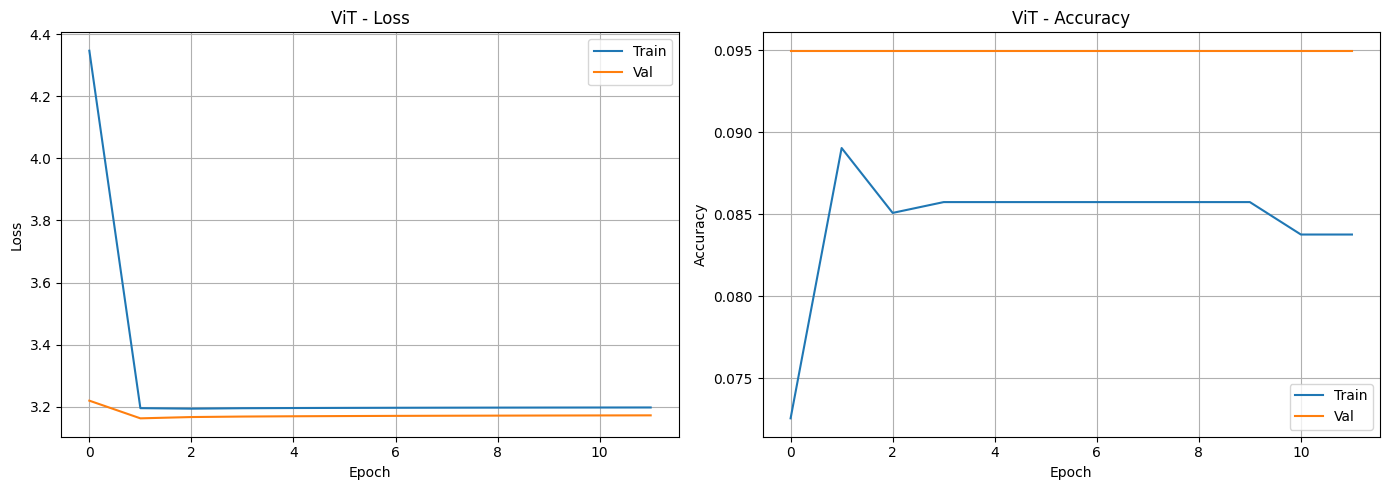

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vit_history.history['loss'], label='Train')
axes[0].plot(vit_history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ViT - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(vit_history.history['accuracy'], label='Train')
axes[1].plot(vit_history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ViT - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'transformers_baseline_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
train_loss, train_acc = vit.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = vit.evaluate(X_val, y_val, verbose=0)

print(f"ViT baseline:")
print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

I0000 00:00:1773414208.220948   25033 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20867__.28


ViT baseline:
  Train - Loss: 3.1620, Acc: 0.0970
  Val   - Loss: 3.1625, Acc: 0.0950


## 4. Submission

In [19]:
final_vit = create_naive_too_simple_vision_transformer((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
final_vit.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
X_all, y_all = load_images_from_df(all_train_df, TRAIN_IMG_DIR)

best_epoch = np.argmin(vit_history.history['val_loss']) + 1
print(f"Best epoch from val: {best_epoch}")

final_vit.fit(
    X_all, y_all,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"Final train accuracy: {final_vit.evaluate(X_all, y_all, verbose=0)[1]:.4f}")

Best epoch from val: 2
Epoch 1/2


I0000 00:00:1773414215.299195   25034 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_116111__.100


54/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0821 - loss: 4.6748

I0000 00:00:1773414219.197657   25033 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_116111__.100
I0000 00:00:1773414219.502661   28374 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_150', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1773414219.525298   28367 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_150', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1773414220.130274   28367 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_76', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1773414220.216254   28379 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_76', 40 bytes spill stores, 40 bytes spill loads

I0000 00:00:1773414220.261743   28368 subprocess_c

60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step - accuracy: 0.0860 - loss: 3.9030
Epoch 2/2
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1024 - loss: 3.1880


I0000 00:00:1773414233.450684   25035 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117416__.28
I0000 00:00:1773414234.697989   25034 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117416__.28


Final train accuracy: 0.0897


In [20]:
embedding_model = keras.Model(
    inputs=final_vit.input,
    outputs=final_vit.layers[-2].output
)

test_filenames = sorted(test_images.keys())
test_array = np.array([test_images[f] for f in test_filenames])

test_embeddings = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embeddings shape: {test_embeddings.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}

I0000 00:00:1773414236.249424   25033 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_118162__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 10s 920ms/step

I0000 00:00:1773414237.193003   25034 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_118629__.19
I0000 00:00:1773414237.492863   29155 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773414237.960813   29157 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773414238.048459   29145 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773414238.792942   29153 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773414238.888362   29147 subprocess_compilation.cc:348]

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step
Embeddings shape: (371, 204)


In [21]:
query_idx = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.sum(
    test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx],
    axis=1
)
similarities = np.clip(similarities, 0, 1)

print(f"Similarities: {len(similarities)} pairs")
print(f"Min: {similarities.min():.4f}, Max: {similarities.max():.4f}, Mean: {similarities.mean():.4f}")
print(f"Unique values: {len(np.unique(np.round(similarities, 4)))}")

Similarities: 137270 pairs
Min: 1.0000, Max: 1.0000, Mean: 1.0000
Unique values: 1


In [22]:
submission = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

submission_path = os.path.join(SUBMISSION_DIR, 'submission_transformers_baseline.csv')
submission.to_csv(submission_path, index=False)

print(f"Saved: {submission_path}")
display(submission.head(10))

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

Saved: /home/franck/jaguar/submissions/submission_transformers_baseline.csv


,row_id,similarity
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0
5,5,1.0
6,6,1.0
7,7,1.0
8,8,1.0
9,9,1.0


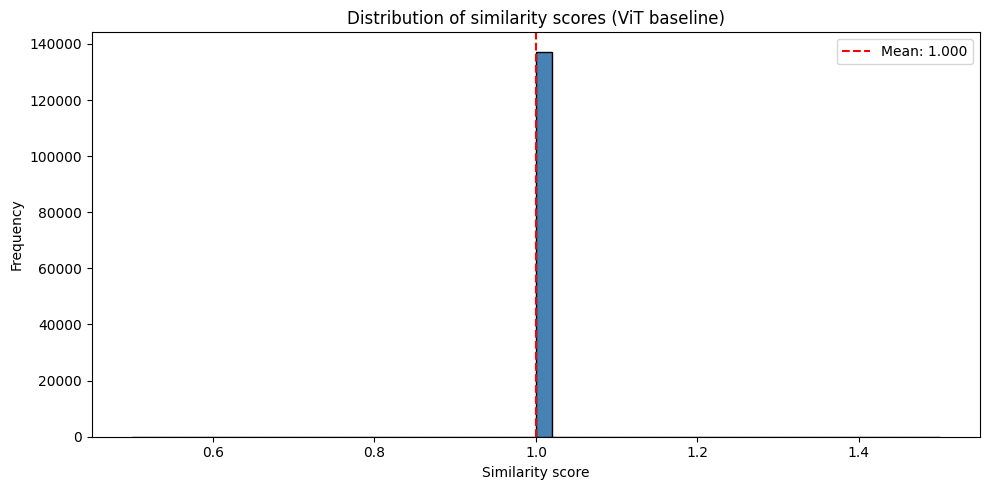

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Similarity score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of similarity scores (ViT baseline)')
ax.axvline(x=similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_distribution_vit.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

In [24]:
print(f"""
ViT baseline:
  Train: {train_acc:.4f}, Val: {val_acc:.4f}
  Best epoch: {best_epoch}
  Embedding dim: {test_embeddings.shape[1]}

vs CNN baseline (notebook 04):
  Train ~0.10, Val ~0.10

Submission -> {submission_path}
""")


ViT baseline:
  Train: 0.0970, Val: 0.0950
  Best epoch: 2
  Embedding dim: 204

vs CNN baseline (notebook 04):
  Train ~0.10, Val ~0.10

Submission -> /home/franck/jaguar/submissions/submission_transformers_baseline.csv

